# Ejercicios Prácticos - Redes Multicapa

##### II DIPLOMA DE EXPERTO EN APRENDIZAJE AUTOMÁTICO AVANZADO EN PYTHON
#### Alumno: Pablo Fazio Arrabal

---

## Ejercicios Básicos

1. Utiliza una red multicapa para modelar el problema de clasificación
multiclase “Wine”, debes basarte en lo visto en la práctica guiada. Puedes usar este código para cargar los datos:



In [1]:
from sklearn.datasets import load_wine
data = load_wine()
X, y = data.data, data.target

**a)** Muestra los valores máximos y mínimos de los rasgos originales. Utiliza un objeto MinMaxScaler para normalizar los rasgos y muestra los valores máximos y mínimos después de normalizar. Divide las muestras en entrenamiento (80%) y validación (20%).

**b)** Crea una red multicapa con cuarenta neuronas ocultas y suficientes neuronas de salida considerando el problema a modelar. Entrena el modelo durante treinta épocas, usa una tasa de aprendizaje del 0.3 y un tamaño de lote de 5.

**c)** Dibuja la evolución de la exactitud en entrenamiento y validación. Comenta los resultados. ¿Dirías que el modelo está sobreajustado o subajustado? Razona tu respuesta.

**d)** Calcula las predicciones para las muestras de validación y, para aquellas muestras mal clasificadas, imprime por pantalla la siguiente información:

  i) La clase deseada.

  ii) La clase predicha.

  iii) Las probabilidades de las diferentes clases.
  
Toma la siguiente captura como ejemplo:

<div align="center">
        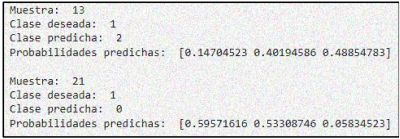
</div>


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# APARTADO A)

print(f'Valores máximos originales: {X.max(axis=0)}')
print(f'Valores mínimos originales: {X.min(axis=0)}')

# Normalizamos los rasgos con MinMaxScaler
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

# Mostramos los valores máximos y mínimos después de normalizar
print(f'Valores máximos normalizados: {X_norm.max(axis=0)}')
print(f'Valores mínimos normalizados: {X_norm.min(axis=0)}')

# Dividimos las muestras en entrenamiento (80%) y validación (20%)
X_ent, X_val, y_ent, y_val = train_test_split(X_norm, y, test_size=0.2, random_state = 10, stratify = y)

Valores máximos originales: [1.483e+01 5.800e+00 3.230e+00 3.000e+01 1.620e+02 3.880e+00 5.080e+00
 6.600e-01 3.580e+00 1.300e+01 1.710e+00 4.000e+00 1.680e+03]
Valores mínimos originales: [1.103e+01 7.400e-01 1.360e+00 1.060e+01 7.000e+01 9.800e-01 3.400e-01
 1.300e-01 4.100e-01 1.280e+00 4.800e-01 1.270e+00 2.780e+02]
Valores máximos normalizados: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Valores mínimos normalizados: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [3]:
# Funciones auxiliares

from sklearn.metrics import accuracy_score

def calcula_exactitud(y_real, y_pred):
    return accuracy_score(y_real, y_pred)

def dibujar_historial(hist_ent, hist_val, titulo):
    plt.figure(figsize=(8,4))
    plt.plot(hist_ent, label='Entrenamiento')
    plt.plot(hist_val, label='Validación')
    plt.xlabel('Época')
    plt.ylabel('Exactitud')
    plt.title(titulo)
    plt.legend()
    plt.grid(False)
    plt.show()

def entrenar_por_epocas(modelo, X_ent, y_ent, X_val, y_val, epocas):

    historial_ent = []
    historial_val = []

    for epoca in range(epocas):

        modelo.max_iter = epoca + 1
        modelo.fit(X_ent, y_ent)

        pred_ent = modelo.predict(X_ent)
        pred_val = modelo.predict(X_val)

        acc_ent = accuracy_score(y_ent, pred_ent)
        acc_val = accuracy_score(y_val, pred_val)

        historial_ent.append(acc_ent)
        historial_val.append(acc_val)

    return historial_ent, historial_val

In [4]:
# APARTADO B)

# Creamos red multicapa como se nos pide en el enunciado con tamaño de lote 5
# y learning rate de 0.3

modelo_wine = MLPClassifier(
    hidden_layer_sizes=(40,),
    activation='logistic',
    learning_rate_init=0.3,
    batch_size=5,
    random_state=10
)

hist_ent_wine, hist_val_wine = entrenar_por_epocas(
    modelo_wine,
    X_ent,
    y_ent,
    X_val,
    y_val,
    epocas=30
)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (4) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

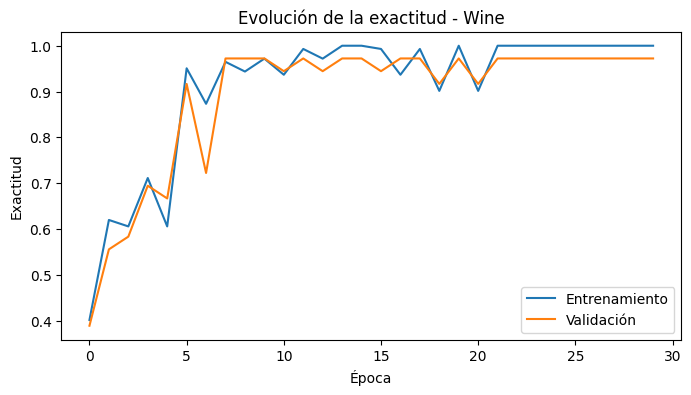

In [5]:
# APARTADO C)

# Dibujamos la gráfica

dibujar_historial(
    hist_ent_wine,
    hist_val_wine,
    'Evolución de la exactitud - Wine'
)

**APARTADO C)**

Al observar el gráfico, la exactitud en entrenamiento y validación tiende a subir y estabilizarse a lo largo de las 30 épocas. Las curvas de entrenamiento y validación están cerca y ambas muestran una exactitud alta, el modelo generaliza correctamente.

In [6]:
# APARTADO D)

y_pred_val = modelo_wine.predict(X_val)
prob_val = modelo_wine.predict_proba(X_val)

# Encontramos los índices de las muestras mal clasificadas
mal_clasificadas = np.where(y_val != y_pred_val)[0]

for idx in mal_clasificadas:
    print(f"Muestra: {idx}")
    print(f"Clase deseada: {y_val[idx]}")
    print(f"Clase predicha: {y_pred_val[idx]}")

    # Formateamos las probabilidades para que se impriman como un array
    probs_str = " ".join([str(p) for p in prob_val[idx]])
    print(f"Probabilidades predichas: [{probs_str}]")

Muestra: 17
Clase deseada: 0
Clase predicha: 1
Probabilidades predichas: [0.29628634867952464 0.7035901236328366 0.00012352768763878067]


2.  Utiliza redes multicapa para modelar el problema de clasificación multiclase “Olivetti_faces”, debes basarte en lo visto en la práctica guiada. Puedes usar este código para cargar los datos:

    

In [7]:
from sklearn.datasets import fetch_olivetti_faces
data = fetch_olivetti_faces()
X, y = data.data, data.target

**a)** Normaliza las muestras y divídelas en entrenamiento (80%) y validación (20%).

**b)** Configura una red multicapa y entrénala para que logre una exactitud en validación igual o superior al 95% en aproximadamente 100 épocas de entrenamiento.

**c)** Configura una red multicapa con los mismos hiperparámetros que la del apartado “b”, pero con diez neuronas ocultas.

**d)** Configura una red multicapa con los mismos hiperparámetros y neuronas que la del apartado “b”, pero donde la tasa de aprendizaje sea una décima parte que la elegida en “b”.

**e)** Dibuja un gráfico con los rendimientos en entrenamiento y validación de los tres modelos anteriores, el resultado deberá ser aproximadamente como el siguiente (dibuja la leyenda correspondiente):


<div align="center">
        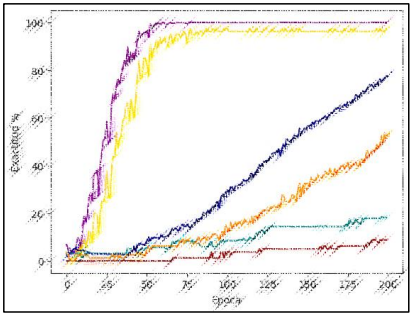
</div>

**f)** Razona por qué evoluciona así el rendimiento en cada uno de los tres modelos.

**g)** ¿Crees que alguno de estos modelos no convergerá a una solución con exactitud superior al 95%?, ¿por qué?

In [8]:
# Aplicamos MinMaxScaler de forma explícita de nuevo
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

# Dividimos las muestras en entrenamiento (80%) y validación (20%)
X_ent, X_val, y_ent, y_val = train_test_split(
    X_norm, y, test_size=0.2, random_state=10, stratify=y
)

In [9]:
def entrenar_por_epocas_2(modelo, X_ent, y_ent, X_val, y_val, epocas):

    historial_ent = []
    historial_val = []

    for epoca in range(epocas):

        modelo.fit(X_ent, y_ent)

        pred_ent = modelo.predict(X_ent)
        pred_val = modelo.predict(X_val)

        acc_ent = accuracy_score(y_ent, pred_ent)
        acc_val = accuracy_score(y_val, pred_val)

        historial_ent.append(acc_ent)
        historial_val.append(acc_val)

    return historial_ent, historial_val

In [10]:
# APARTADOS B), C) y D)

# Definimos el número total de épocas fijado
MAX_EPOCHS = 100

# Configuración del Modelo B

mlp_b = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    learning_rate_init=0.001,
    batch_size=16,
    max_iter=1,
    warm_start=True,
    random_state=10
)

hist_ent_b, hist_val_b = entrenar_por_epocas_2(
    mlp_b,
    X_ent,
    y_ent,
    X_val,
    y_val,
    epocas=MAX_EPOCHS
)

# Configuración del Modelo C

mlp_c = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    learning_rate_init=0.001,
    batch_size=16,
    max_iter=1,
    warm_start=True,
    random_state=10
)

hist_ent_c, hist_val_c = entrenar_por_epocas_2(
    mlp_c,
    X_ent,
    y_ent,
    X_val,
    y_val,
    epocas=MAX_EPOCHS
)

# Configuración del Modelo D

mlp_d = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    learning_rate_init=0.0001,
    batch_size=16,
    max_iter=1,
    warm_start=True,
    random_state=10
)

hist_ent_d, hist_val_d = entrenar_por_epocas_2(
    mlp_d,
    X_ent,
    y_ent,
    X_val,
    y_val,
    epocas=MAX_EPOCHS
)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

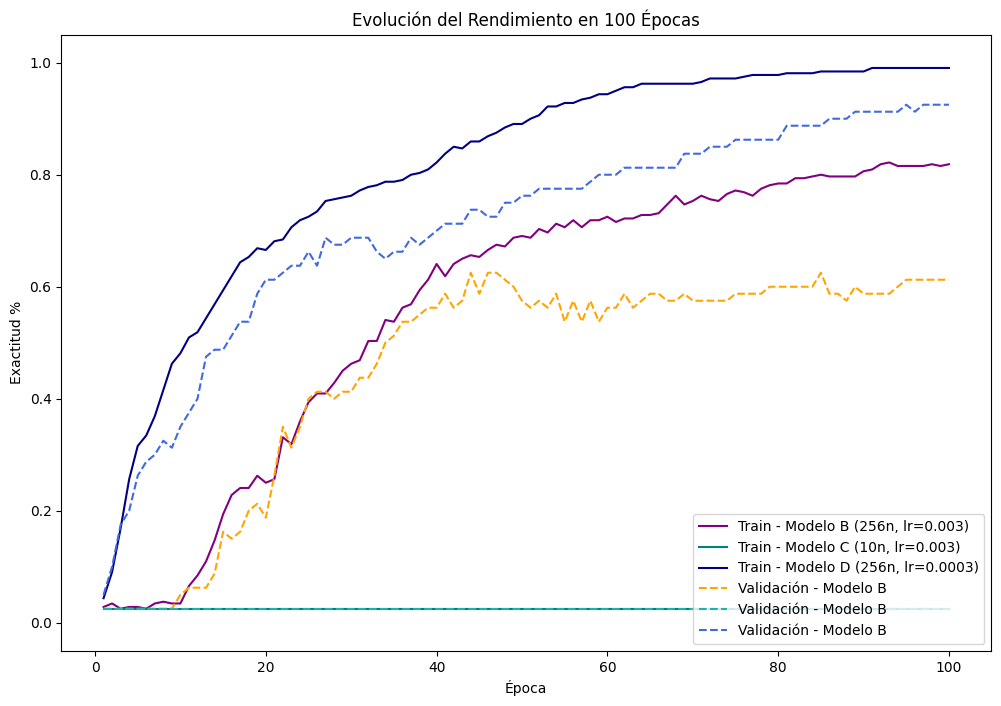

In [11]:
# APARTADO E)

plt.figure(figsize=(12, 8))
epocas = range(1, MAX_EPOCHS + 1)

# Curvas de entrenamiento
plt.plot(epocas, hist_ent_b, color='purple', linestyle='-', label='Train - Modelo B (256n, lr=0.003)')
plt.plot(epocas, hist_ent_c, color='teal', linestyle='-', label='Train - Modelo C (10n, lr=0.003)')
plt.plot(epocas, hist_ent_d, color='navy', linestyle='-', label='Train - Modelo D (256n, lr=0.0003)')

# Curvas de validación
plt.plot(epocas, hist_val_b, color='orange', linestyle='--', label='Validación - Modelo B')
plt.plot(epocas, hist_val_c, color='lightseagreen', linestyle='--', label='Validación - Modelo C')
plt.plot(epocas, hist_val_d, color='royalblue', linestyle='--', label='Validación - Modelo D')

plt.title('Evolución del Rendimiento en 100 Épocas')
plt.xlabel('Época')
plt.ylabel('Exactitud %')
plt.ylim(-0.05, 1.05)
plt.legend(loc='lower right')
plt.show()

**APARTADO F)**

Razones de evolución de cada modelo:

- El primer modelo (modelo B) posee suficiente capacidad para aprender representaciones complejas y converge rápidamente.
- El modelo con únicamente 10 neuronas ocultas (modelo C) tiene menor capacidad y aprende más lentamente.
- El modelo con una tasa de aprendizaje diez veces menor (modelo D) converge de manera mucho más lenta porque las actualizaciones de pesos son pequeñas.

**APARTADO G)**

El modelo con pocas neuronas podría necesitar muchas más épocas para alcanzar el 95%. El modelo con tasa de aprendizaje muy pequeña también tardaría bastante en converger.

## Ejercicio Avanzado

3. Utiliza redes multicapa para modelar el problema de clasificación binario “Breast cancer”. Puedes usar este código para cargar los datos:


In [12]:
from sklearn.datasets import load_breast_cancer
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target

**a)** Normaliza las muestras y divídelas en entrenamiento (80%) y validación (20%).

**b)** Configura varias redes multicapa, cada una con los siguientes números de neuronas ocultas: 1, 2, 4, 8, 16, 32, 64 y 128. Configura el resto de los parámetros y entrénalas durante 100 épocas de entrenamiento, para obtener una exactitud en entrenamiento y validación alrededor del 96%.

**c)** Dibuja un gráfico con los rendimientos en entrenamiento y validación de todos los modelos entrenados. Dibuja la leyenda que corresponda.

**d)** Razona por qué evoluciona así el rendimiento.

In [14]:
# APARTADO A)

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X_ent, X_val, y_ent, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10,
    stratify=y
)

In [15]:
# APARTADO C)

neuronas = [1, 2, 4, 8, 16, 32, 64, 128]
acc_ent = []
acc_val = []

for n in neuronas:

    modelo = MLPClassifier(
        hidden_layer_sizes=(n,),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=100,
        random_state=10
    )

    modelo.fit(X_ent, y_ent)

    pred_ent = modelo.predict(X_ent)
    pred_val = modelo.predict(X_val)

    acc_ent.append(accuracy_score(y_ent, pred_ent))
    acc_val.append(accuracy_score(y_val, pred_val))

    print(f"Neuronas: {n}")
    print(f"Exactitud entrenamiento: {acc_ent[-1]:.4f}")
    print(f"Exactitud validación: {acc_val[-1]:.4f}")
    print("-"*40)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Neuronas: 1
Exactitud entrenamiento: 0.6264
Exactitud validación: 0.6316
----------------------------------------
Neuronas: 2
Exactitud entrenamiento: 0.5824
Exactitud validación: 0.4912
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Neuronas: 4
Exactitud entrenamiento: 0.9275
Exactitud validación: 0.8947
----------------------------------------
Neuronas: 8
Exactitud entrenamiento: 0.8901
Exactitud validación: 0.8596
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Neuronas: 16
Exactitud entrenamiento: 0.9253
Exactitud validación: 0.8684
----------------------------------------
Neuronas: 32
Exactitud entrenamiento: 0.9319
Exactitud validación: 0.8947
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Neuronas: 64
Exactitud entrenamiento: 0.9407
Exactitud validación: 0.9211
----------------------------------------
Neuronas: 128
Exactitud entrenamiento: 0.9604
Exactitud validación: 0.9474
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


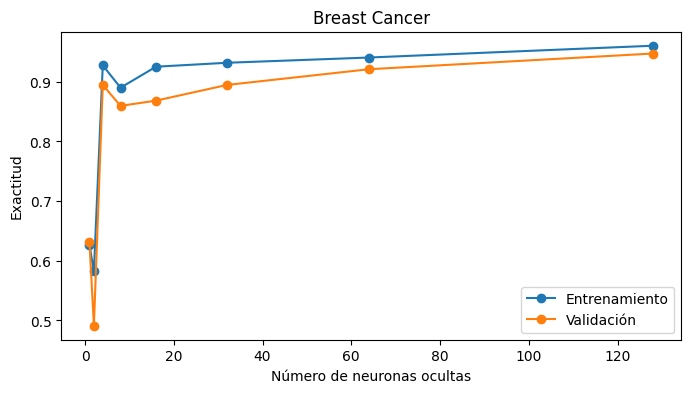

In [16]:
# APARTADO C)

plt.figure(figsize=(8,4))

plt.plot(neuronas, acc_ent, marker='o', label='Entrenamiento')
plt.plot(neuronas, acc_val, marker='o', label='Validación')

plt.xlabel('Número de neuronas ocultas')
plt.ylabel('Exactitud')
plt.title('Breast Cancer')
plt.legend()
plt.show()

**APARTADO D)**

Al aumentar el número de neuronas ocultas, la capacidad del modelo también aumenta.
Inicialmente mejora el rendimiento porque la red puede aprender patrones más complejos.
Sin embargo, cuando el número de neuronas es demasiado grande, el modelo puede empezar a sobreajustarse.

## Ejercicio Experto

4. Utiliza redes multicapa para modelar un problema de clasificación binario asociado al fractal de Mandelbrot. Puedes usar el código del fichero `MandelbrotFractalClassification.ipynb` que encontrarás en el campus virtual.

    **a)** Dibuja el fractal de Mandelbrot usando la función `mandelbrot_matrix` con los siguientes parámetros:

    ```
    start_a = -2
    end_a = 1
    num_a = 600
    start_b = -1
    end_b = 1
    num_b = 400
    ```

    **b)** Normaliza las muestras y divídelas en entrenamiento (80%) y validación (20%).

    **c)** Configura varias redes multicapa, cada una con los siguientes números de neuronas ocultas: 4, 8, 12, 16, 20, 24, 28 y 32. Configura el resto de los parámetros y entrénalas durante 1000 épocas de entrenamiento, para obtener una exactitud en entrenamiento y validación alrededor del 95%.

    **d)** Dibuja un gráfico con los rendimientos en entrenamiento y validación de todos los modelos entrenados. Dibuja la leyenda que corresponda.

    **e)** Razona por qué evoluciona así el rendimiento.

    **f)** Dibuja la probabilidad de la clase 0 para todos los puntos del plano que se graficaron en el apartado a.

    **g)** Dibuja la salida deseada o “ground truth” para todos los puntos del plano que se graficaron en el apartado a.


In [21]:
# Definimos las funciones del cuaderno enunciado

MAX_ITERATIONS = 80
def mandelbrot_point(a,b):
    c = complex(a,b)
    z = 0
    n = 0
    while abs(z) <= 2 and n < MAX_ITERATIONS:
        z = z*z + c
        n += 1
    color_pixel = 1.0 - (n / MAX_ITERATIONS)
    return color_pixel

def mandelbrot_matrix(start_a, end_a, num_a, start_b, end_b, num_b):
  values_a = np.linspace(start_a, end_a, num_a)
  values_b = np.linspace(start_b, end_b, num_b)
  matrix = np.zeros((values_a.size, values_b.size))
  for index_a, a in enumerate(values_a):
      for index_b, b in enumerate(values_b):
          matrix[index_a, index_b] = mandelbrot_point(a, b)
  return matrix

def mandelbrot_classification(start_a, end_a, start_b, end_b, num_samples):
  input_values = np.zeros((num_samples, 2))
  input_values[:, 0] = np.random.uniform(start_a, end_a, size=(num_samples,) )
  input_values[:, 1] = np.random.uniform(start_b, end_b, size=(num_samples,) )
  output_values = np.zeros((num_samples, ), dtype=np.int32)
  for ndx in range(num_samples):
    output_values[ndx] = mandelbrot_point(input_values[ndx, 0], input_values[ndx, 1]) > 0.5
  return input_values, output_values

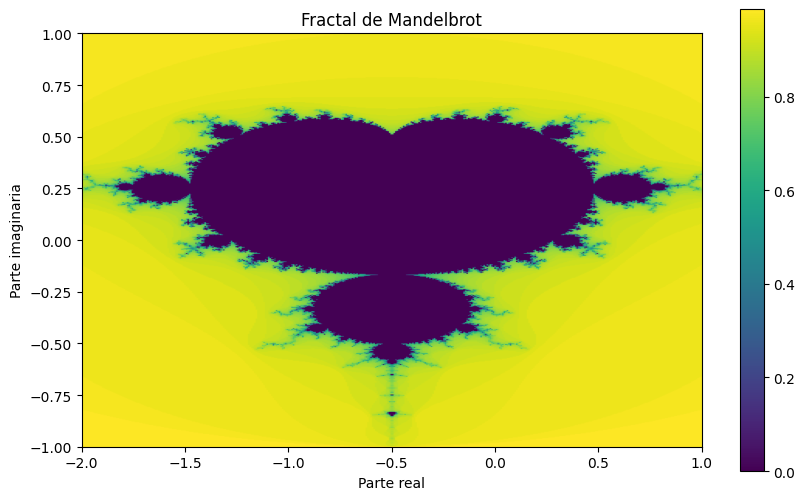

In [30]:
# APARTADO A)

matriz = mandelbrot_matrix(
    start_a=-2,
    end_a=1,
    num_a=600,
    start_b=-1,
    end_b=1,
    num_b=400
)

X, y = mandelbrot_classification(
    start_a=-2,
    end_a=1,
    start_b=-1,
    end_b=1,
    num_samples=240000
)

plt.figure(figsize=(10,6))
plt.imshow(matriz, extent=[-2,1,-1,1], origin='lower')
plt.title('Fractal de Mandelbrot')
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.colorbar()
plt.show()

In [31]:
# APARTADO B)

scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

X_ent, X_val, y_ent, y_val = train_test_split(
    X_norm,
    y,
    test_size=0.2,
    random_state=10,
    stratify=y
)

In [32]:
# APARTADO C)

neuronas = [4, 8, 12, 16, 20, 24, 28, 32]

historial = {}

for n in neuronas:

    modelo = MLPClassifier(
        hidden_layer_sizes=(n,),
        activation='tanh',
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=10
    )

    modelo.fit(X_ent, y_ent)

    acc_ent = modelo.score(X_ent, y_ent)
    acc_val = modelo.score(X_val, y_val)

    historial[n] = (acc_ent, acc_val)

    print(f"{n} neuronas -> Entrenamiento: {acc_ent:.4f}, Validación: {acc_val:.4f}")

4 neuronas -> Entrenamiento: 0.8239, Validación: 0.8237
8 neuronas -> Entrenamiento: 0.9601, Validación: 0.9599
12 neuronas -> Entrenamiento: 0.9577, Validación: 0.9571
16 neuronas -> Entrenamiento: 0.9611, Validación: 0.9610
20 neuronas -> Entrenamiento: 0.9599, Validación: 0.9595
24 neuronas -> Entrenamiento: 0.9626, Validación: 0.9621
28 neuronas -> Entrenamiento: 0.9623, Validación: 0.9622
32 neuronas -> Entrenamiento: 0.9625, Validación: 0.9624


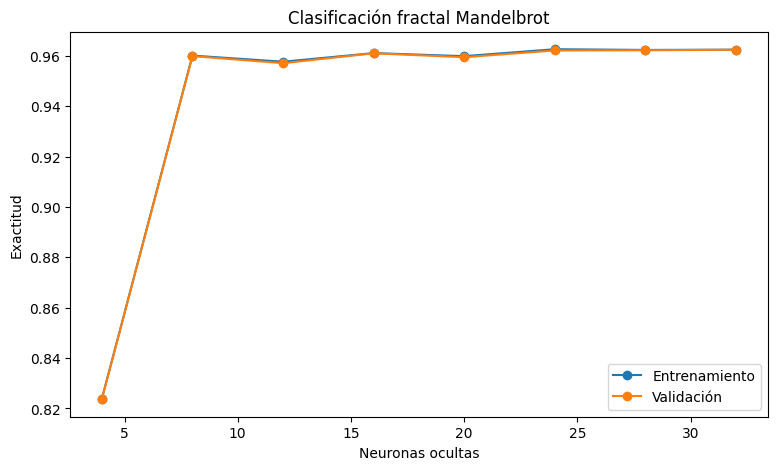

In [33]:
# APARTADO D)

plt.figure(figsize=(9,5))

plt.plot(
    list(historial.keys()),
    [v[0] for v in historial.values()],
    marker='o',
    label='Entrenamiento'
)

plt.plot(
    list(historial.keys()),
    [v[1] for v in historial.values()],
    marker='o',
    label='Validación'
)

plt.xlabel('Neuronas ocultas')
plt.ylabel('Exactitud')
plt.title('Clasificación fractal Mandelbrot')
plt.legend()
plt.show()


**APARTADO E)**

El fractal de Mandelbrot define fronteras extremadamente complejas y no lineales.
Al aumentar el número de neuronas ocultas, la red tiene más capacidad para aproximar dichas fronteras.
Sin embargo, un exceso de complejidad también puede producir sobreajuste.

In [ ]:
# APARTADOS F) y G)

modelo_final = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='tanh',
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=10
)

modelo_final.fit(X_ent, y_ent)

probabilidades = modelo_final.predict_proba(X_norm)[:,0]

prob_img = probabilidades.reshape(400, 600)

plt.figure(figsize=(10,6))
plt.imshow(prob_img, extent=[-2,1,-1,1], origin='lower')
plt.title('Probabilidad de clase 0')
plt.colorbar()
plt.show()

plt.figure(figsize=(10,6))
plt.imshow(matriz, extent=[-2,1,-1,1], origin='lower')
plt.title('Ground truth')
plt.colorbar()
plt.show()